**DATA CLEANING**

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("fifa_final.csv")
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,Work Rate,Body Type,Position,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94.0,94.0,FC Barcelona,€110.5M,€565K,Left,Medium/ Medium,Messi,RF,5'7,159lbs,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94.0,94.0,Juventus,€77M,€405K,Right,High/ Low,C. Ronaldo,ST,6'2,183lbs,€127.1M
2,190871,Neymar Jr,26,Brazil,92.0,93.0,Paris Saint-Germain,€118.5M,€290K,Right,High/ Medium,Neymar,LW,5'9,150lbs,€228.1M
3,193080,De Gea,27,Spain,91.0,93.0,Manchester United,€72M,€260K,Right,Medium/ Medium,Lean,GK,6'4,168lbs,€138.6M
4,192985,K. De Bruyne,27,Belgium,91.0,92.0,Manchester City,€102M,€355K,Right,High/ High,Normal,RCM,5'11,154lbs,€196.4M


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14250 entries, 0 to 14249
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              14250 non-null  int64  
 1   Name            14250 non-null  object 
 2   Age             14250 non-null  int64  
 3   Nationality     14248 non-null  object 
 4   Overall         14248 non-null  float64
 5   Potential       14248 non-null  float64
 6   Club            14045 non-null  object 
 7   Value           14248 non-null  object 
 8   Wage            14248 non-null  object 
 9   Preferred Foot  14200 non-null  object 
 10  Work Rate       14200 non-null  object 
 11  Body Type       14200 non-null  object 
 12  Position        14195 non-null  object 
 13  Height          14200 non-null  object 
 14  Weight          14200 non-null  object 
 15  Release Clause  12895 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 1.7+ MB


In [4]:
df.describe()

,ID,Age,Overall,Potential
count,14250.000000,14250.000000,14248.000000,14248.000000
mean,208911.566035,26.178456,68.834363,72.467715
std,30026.243237,4.334310,5.200717,5.786637
min,16.000000,16.000000,61.000000,61.000000
25%,193529.000000,23.000000,65.000000,68.000000
50%,213693.500000,26.000000,68.000000,72.000000
75%,230404.750000,29.000000,72.000000,76.000000
max,246617.000000,45.000000,94.000000,95.000000


*DUPLICATES*

In [5]:
print(df.duplicated().sum())

9


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
print(df.duplicated().sum())

0


*MISSING VALUES*

In [8]:
df.isnull().sum()

ID                   0
Name                 0
Age                  0
Nationality          1
Overall              1
Potential            1
Club               204
Value                1
Wage                 1
Preferred Foot      49
Work Rate           49
Body Type           49
Position            54
Height              49
Weight              49
Release Clause    1354
dtype: int64

In [9]:
# 14250 entries in total
# release clause doesn't have any logical correlation with preferred foot so we can drop

df = df.drop("Release Clause", axis=1)

In [10]:
df.isnull().sum()

ID                  0
Name                0
Age                 0
Nationality         1
Overall             1
Potential           1
Club              204
Value               1
Wage                1
Preferred Foot     49
Work Rate          49
Body Type          49
Position           54
Height             49
Weight             49
dtype: int64

In [11]:
# preferred foot is our target column, we don't want to fabricate values for it in case it ruins our accuracy
# so we can drop all rows where the preferred foot is missing

df.dropna(subset=["Preferred Foot"], inplace=True)

In [12]:
df.isnull().sum()

ID                  0
Name                0
Age                 0
Nationality         0
Overall             0
Potential           0
Club              203
Value               0
Wage                0
Preferred Foot      0
Work Rate           0
Body Type           0
Position            5
Height              0
Weight              0
dtype: int64

In [13]:
# since only 5 values are missing in position we can just drop those (very small percentage out of 14250 rows)

df.dropna(subset=["Position"], inplace=True)

In [14]:
df.isnull().sum()

ID                  0
Name                0
Age                 0
Nationality         0
Overall             0
Potential           0
Club              198
Value               0
Wage                0
Preferred Foot      0
Work Rate           0
Body Type           0
Position            0
Height              0
Weight              0
dtype: int64

In [15]:
# same with club, 198 values is 0.01% of 14250 so records where club is missing can be dropped

df.dropna(subset=["Club"], inplace=True)

In [16]:
df.isnull().sum()

ID                0
Name              0
Age               0
Nationality       0
Overall           0
Potential         0
Club              0
Value             0
Wage              0
Preferred Foot    0
Work Rate         0
Body Type         0
Position          0
Height            0
Weight            0
dtype: int64

*OUTLIERS*

In [17]:
def print_iqr_outliers(df, column):
    """
    Detect and print IQR-based outliers for a given column in a DataFrame.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"IQR Outliers in '{column}':")
    print(outliers[[column]])

    return outliers

In [18]:
# check which columns are numerical columns

df.describe()

,ID,Age,Overall,Potential
count,13989.000000,13989.000000,13989.000000,13989.000000
mean,208760.671885,26.173208,68.860033,72.500608
std,30087.469064,4.336201,5.206062,5.794259
min,16.000000,16.000000,61.000000,61.000000
25%,193429.000000,23.000000,65.000000,68.000000
50%,213589.000000,26.000000,68.000000,72.000000
75%,230358.000000,29.000000,72.000000,76.000000
max,246617.000000,45.000000,94.000000,95.000000


In [19]:
# ID is irrelevant, let's focus on age, overall and potential

print_iqr_outliers(df, 'Age')

IQR Outliers in 'Age':
       Age
41      40
554     39
864     40
1294    40
1952    39
2225    39
2706    39
2821    40
3128    39
3420    39
3550    40
3603    39
4062    39
4187    40
4228    41
4640    39
4646    39
4741    45
5040    39
5101    39
5608    39
6398    39
6861    39
7039    39
7225    41
7427    39
9484    40
10356   40
10487   39
10534   39
10545   42
11456   39
12192   41
12453   40
14129   40


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,Work Rate,Body Type,Position,Height,Weight
41,1179,G. Buffon,40,Italy,88.0,88.0,Paris Saint-Germain,€4M,€77K,Right,Medium/ Medium,Normal,GK,6'4,203lbs
554,49031,S. Sorrentino,39,Italy,80.0,80.0,Chievo Verona,€1M,€10K,Right,Medium/ Medium,Normal,GK,6'1,187lbs
864,153260,Hilton,40,Brazil,78.0,78.0,Montpellier HSC,€ 0,€18K,Right,Medium/ Medium,Normal,CB,5'11,172lbs
1294,14907,A. Bizzarri,40,Argentina,76.0,76.0,Foggia,€525K,€2K,Right,Medium/ Medium,Normal,GK,6'2,196lbs
1952,161468,P. Guiñazú,39,Argentina,75.0,75.0,Club Atlético Talleres,€450K,€10K,Left,Low/ High,Normal,LCM,5'9,150lbs
2225,25420,C. Pizarro,39,Peru,74.0,74.0,SV Werder Bremen,€1.6M,€18K,Right,Medium/ Low,Normal,ST,6'0,185lbs
2706,110638,Cifuentes,39,Spain,73.0,73.0,Cádiz CF,€270K,€4K,Right,Medium/ Medium,Normal,GK,6'3,172lbs
2821,232543,S. Bertoli,40,Argentina,73.0,73.0,Patronato,€270K,€6K,Right,Medium/ Medium,Normal,GK,6'1,179lbs
3128,7647,D. Dainelli,39,Italy,73.0,73.0,Livorno,€270K,€2K,Right,Low/ Medium,Lean,CB,6'3,172lbs
3420,149571,S. Pellissier,39,Italy,72.0,72.0,Chievo Verona,€900K,€10K,Right,Medium/ Low,Normal,ST,5'9,168lbs


In [20]:
print(df["Age"].skew())

0.30341278767077573


In [21]:
# since the age outliers may be important information we can winorize slightly to reduce the skew
# but not get rid of outliers entirely

from scipy.stats.mstats import winsorize 

df["Age"] = winsorize(df["Age"], limits=[0.00, 0.05])
print(df["Age"].skew())

0.13467996288158857


In [22]:
df["Age"] = winsorize(df["Age"], limits=[0.00, 0.07])
print(df["Age"].skew())

0.04786069864858866


In [23]:
# we can stop here, 0.05 can be considered acceptable skewness of a normal distribution

In [24]:
print_iqr_outliers(df, "Potential")

IQR Outliers in 'Potential':
      Potential
0          94.0
1          94.0
2          93.0
3          93.0
4          92.0
...         ...
1149       89.0
1172       89.0
1763       89.0
6102       89.0
7414       89.0

[83 rows x 1 columns]


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,Work Rate,Body Type,Position,Height,Weight
0,158023,L. Messi,31,Argentina,94.0,94.0,FC Barcelona,€110.5M,€565K,Left,Medium/ Medium,Messi,RF,5'7,159lbs
1,20801,Cristiano Ronaldo,33,Portugal,94.0,94.0,Juventus,€77M,€405K,Right,High/ Low,C. Ronaldo,ST,6'2,183lbs
2,190871,Neymar Jr,26,Brazil,92.0,93.0,Paris Saint-Germain,€118.5M,€290K,Right,High/ Medium,Neymar,LW,5'9,150lbs
3,193080,De Gea,27,Spain,91.0,93.0,Manchester United,€72M,€260K,Right,Medium/ Medium,Lean,GK,6'4,168lbs
4,192985,K. De Bruyne,27,Belgium,91.0,92.0,Manchester City,€102M,€355K,Right,High/ High,Normal,RCM,5'11,154lbs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,227535,R. Bentancur,21,Uruguay,77.0,89.0,Juventus,€15.5M,€62K,Right,Medium/ Medium,Lean,RCM,6'2,159lbs
1172,224232,N. Barella,21,Italy,77.0,89.0,Cagliari,€15.5M,€24K,Right,Medium/ Medium,Lean,RCM,5'8,150lbs
1763,225116,A. Meret,21,Italy,75.0,89.0,Napoli,€12M,€24K,Left,Medium/ Medium,Lean,GK,6'3,183lbs
6102,242816,Riqui Puig,18,Spain,69.0,89.0,FC Barcelona,€2.1M,€24K,Right,Medium/ Low,Lean,CM,5'7,123lbs


In [25]:
# potential could be a very important column
# we shouldn't delete the outliers since they represent excellent/not good players
# we should leave the outliers as is as this could be important information

In [26]:
print(df["Potential"].skew())

0.43730878634919285


In [27]:
# skew is representative of the context

In [28]:
print_iqr_outliers(df, "Overall")

IQR Outliers in 'Overall':
     Overall
0       94.0
1       94.0
2       92.0
3       91.0
4       91.0
..       ...
220     83.0
221     83.0
222     83.0
223     83.0
224     83.0

[225 rows x 1 columns]


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,Work Rate,Body Type,Position,Height,Weight
0,158023,L. Messi,31,Argentina,94.0,94.0,FC Barcelona,€110.5M,€565K,Left,Medium/ Medium,Messi,RF,5'7,159lbs
1,20801,Cristiano Ronaldo,33,Portugal,94.0,94.0,Juventus,€77M,€405K,Right,High/ Low,C. Ronaldo,ST,6'2,183lbs
2,190871,Neymar Jr,26,Brazil,92.0,93.0,Paris Saint-Germain,€118.5M,€290K,Right,High/ Medium,Neymar,LW,5'9,150lbs
3,193080,De Gea,27,Spain,91.0,93.0,Manchester United,€72M,€260K,Right,Medium/ Medium,Lean,GK,6'4,168lbs
4,192985,K. De Bruyne,27,Belgium,91.0,92.0,Manchester City,€102M,€355K,Right,High/ High,Normal,RCM,5'11,154lbs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,162240,M. Dembélé,30,Belgium,83.0,83.0,Tottenham Hotspur,€24M,€120K,Left,Medium/ Medium,Normal,CM,6'1,181lbs
221,156616,F. Ribéry,33,France,83.0,83.0,FC Bayern München,€11.5M,€72K,Right,Medium/ Medium,Normal,LM,5'7,159lbs
222,104389,R. Jarstein,33,Norway,83.0,83.0,Hertha BSC,€13M,€33K,Right,Medium/ Medium,Normal,GK,6'3,181lbs
223,53302,D. De Rossi,33,Italy,83.0,83.0,Roma,€8M,€80K,Right,Medium/ High,Normal,RDM,6'0,183lbs


In [29]:
# again overall is similar to potential, represents best and worst players
# let's check the skew

print(df["Overall"].skew())

0.8383945515228939


In [30]:
# important information so we can leave these outliers

*ENCODING CATEGORICAL ATTRIBUTES*

In [31]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,Work Rate,Body Type,Position,Height,Weight
0,158023,L. Messi,31,Argentina,94.0,94.0,FC Barcelona,€110.5M,€565K,Left,Medium/ Medium,Messi,RF,5'7,159lbs
1,20801,Cristiano Ronaldo,33,Portugal,94.0,94.0,Juventus,€77M,€405K,Right,High/ Low,C. Ronaldo,ST,6'2,183lbs
2,190871,Neymar Jr,26,Brazil,92.0,93.0,Paris Saint-Germain,€118.5M,€290K,Right,High/ Medium,Neymar,LW,5'9,150lbs
3,193080,De Gea,27,Spain,91.0,93.0,Manchester United,€72M,€260K,Right,Medium/ Medium,Lean,GK,6'4,168lbs
4,192985,K. De Bruyne,27,Belgium,91.0,92.0,Manchester City,€102M,€355K,Right,High/ High,Normal,RCM,5'11,154lbs


In [32]:
# columns that need to be encoded:
# nationality, club, value, wage, preferred foot, work rate, body type, position, height, weight

# value, wage, height and weight should be numerical columns, need to do regex and conversion
# label encoding: work rate, body type, preferred foot
# one-hot encoding: nationality, club, position

In [33]:
# let's get label encoding out of the way

print(df["Work Rate"].value_counts())

Work Rate
Medium/ Medium    6841
High/ Medium      2738
Medium/ High      1474
High/ High         936
Medium/ Low        684
High/ Low          575
Low/ High          378
Low/ Medium        335
Low/ Low            28
Name: count, dtype: int64


In [34]:
print(df["Body Type"].value_counts())

Body Type
Normal                 8355
Lean                   4654
Stocky                  973
Messi                     1
C. Ronaldo                1
Neymar                    1
Courtois                  1
PLAYER_BODY_TYPE_25       1
Shaqiri                   1
Akinfenwa                 1
Name: count, dtype: int64


In [35]:
print(df["Preferred Foot"].value_counts())

Preferred Foot
Right    10569
Left      3420
Name: count, dtype: int64


In [36]:
# let's drop the weird body type values first

valid_body_types = ['Normal', 'Lean', 'Stocky']
df = df[df['Body Type'].isin(valid_body_types)]

In [37]:
print(df["Body Type"].value_counts())

Body Type
Normal    8355
Lean      4654
Stocky     973
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Work Rate"] = le.fit_transform(df["Work Rate"])
df["Body Type"] = le.fit_transform(df["Body Type"])
df["Preferred Foot"] = le.fit_transform(df["Preferred Foot"])

In [39]:
print(df["Work Rate"].value_counts())
print(df["Body Type"].value_counts())
print(df["Preferred Foot"].value_counts())

Work Rate
8    6838
2    2736
6    1474
0     936
7     684
1     574
3     378
5     335
4      27
Name: count, dtype: int64
Body Type
1    8355
0    4654
2     973
Name: count, dtype: int64
Preferred Foot
1    10566
0     3416
Name: count, dtype: int64


In [40]:
# now the one-hot encoding

df = pd.get_dummies(df, columns=['Nationality'], prefix='Nat')
df = pd.get_dummies(df, columns=['Club'], prefix='Club')
df = pd.get_dummies(df, columns=['Position'], prefix='Pos')

In [41]:
df.head()

,ID,Name,Age,Overall,Potential,Value,Wage,Preferred Foot,Work Rate,Body Type,...,Pos_RB,Pos_RCB,Pos_RCM,Pos_RDM,Pos_RF,Pos_RM,Pos_RS,Pos_RW,Pos_RWB,Pos_ST
3,193080,De Gea,27,91.0,93.0,€72M,€260K,1,8,0,...,False,False,False,False,False,False,False,False,False,False
4,192985,K. De Bruyne,27,91.0,92.0,€102M,€355K,1,0,1,...,False,False,True,False,False,False,False,False,False,False
5,183277,E. Hazard,27,91.0,91.0,€93M,€340K,1,2,1,...,False,False,False,False,False,False,False,False,False,False
6,177003,L. Modrić,32,91.0,91.0,€67M,€420K,1,0,0,...,False,False,True,False,False,False,False,False,False,False
7,176580,L. Suárez,31,91.0,91.0,€80M,€455K,1,2,1,...,False,False,False,False,False,False,True,False,False,False


In [49]:
# now we need to fix the ones that should be numeric - value, wage, height, weight

# remove lbs from weight values
df['Weight'] = df['Weight'].str.extract('(\d+)').astype(int)

# height in inches
df['Height'] = df['Height'].str.extract('(\d+)\'(\d+)?').apply(
    lambda x: int(x[0])*12 + (int(x[1]) if pd.notna(x[1]) else 0), axis=1
)

# both value and wage are similar, convert with care for M or K
df['Value'] = df['Value'].str.extract('([\d.]+)([MK])?').apply(
    lambda x: float(x[0]) * (1e6 if x[1]=='M' else 1e3 if x[1]=='K' else 1), axis=1
)

df['Wage'] = df['Wage'].str.extract('([\d.]+)([MK])?').apply(
    lambda x: float(x[0]) * (1e6 if x[1]=='M' else 1e3 if x[1]=='K' else 1), axis=1
)

In [50]:
df.head()

,ID,Name,Age,Overall,Potential,Value,Wage,Preferred Foot,Work Rate,Body Type,...,Pos_RB,Pos_RCB,Pos_RCM,Pos_RDM,Pos_RF,Pos_RM,Pos_RS,Pos_RW,Pos_RWB,Pos_ST
3,193080,De Gea,27,91.0,93.0,72000000.0,260000.0,1,8,0,...,False,False,False,False,False,False,False,False,False,False
4,192985,K. De Bruyne,27,91.0,92.0,102000000.0,355000.0,1,0,1,...,False,False,True,False,False,False,False,False,False,False
5,183277,E. Hazard,27,91.0,91.0,93000000.0,340000.0,1,2,1,...,False,False,False,False,False,False,False,False,False,False
6,177003,L. Modrić,32,91.0,91.0,67000000.0,420000.0,1,0,0,...,False,False,True,False,False,False,False,False,False,False
7,176580,L. Suárez,31,91.0,91.0,80000000.0,455000.0,1,2,1,...,False,False,False,False,False,False,True,False,False,False


In [51]:
print(df.columns.tolist())

['ID', 'Name', 'Age', 'Overall', 'Potential', 'Value', 'Wage', 'Preferred Foot', 'Work Rate', 'Body Type', 'Height', 'Weight', 'Nat_Afghanistan', 'Nat_Albania', 'Nat_Algeria', 'Nat_Andorra', 'Nat_Angola', 'Nat_Antigua & Barbuda', 'Nat_Argentina', 'Nat_Armenia', 'Nat_Australia', 'Nat_Austria', 'Nat_Azerbaijan', 'Nat_Barbados', 'Nat_Belarus', 'Nat_Belgium', 'Nat_Benin', 'Nat_Bermuda', 'Nat_Bolivia', 'Nat_Bosnia Herzegovina', 'Nat_Brazil', 'Nat_Bulgaria', 'Nat_Burkina Faso', 'Nat_Burundi', 'Nat_Cameroon', 'Nat_Canada', 'Nat_Cape Verde', 'Nat_Central African Rep.', 'Nat_Chad', 'Nat_Chile', 'Nat_China PR', 'Nat_Colombia', 'Nat_Comoros', 'Nat_Congo', 'Nat_Costa Rica', 'Nat_Croatia', 'Nat_Cuba', 'Nat_Curacao', 'Nat_Cyprus', 'Nat_Czech Republic', 'Nat_DR Congo', 'Nat_Denmark', 'Nat_Dominican Republic', 'Nat_Ecuador', 'Nat_Egypt', 'Nat_El Salvador', 'Nat_England', 'Nat_Equatorial Guinea', 'Nat_Eritrea', 'Nat_Estonia', 'Nat_Ethiopia', 'Nat_FYR Macedonia', 'Nat_Faroe Islands', 'Nat_Fiji', 'Nat_Fi

In [52]:
df.drop(["ID", "Name"], axis=1, inplace=True)

In [53]:
# normalizing value and wage

df['Value'] = (df['Value'] - df['Value'].min()) / (df['Value'].max() - df['Value'].min())
df['Wage'] = (df['Wage'] - df['Wage'].min()) / (df['Wage'].max() - df['Wage'].min())

In [56]:
# need two more columns to normalize... 

df.describe()

,Age,Overall,Potential,Value,Wage,Preferred Foot,Work Rate,Body Type,Height,Weight
count,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000
mean,26.045916,68.851309,72.493492,0.029922,0.024470,0.755686,5.528465,0.736733,71.403161,167.024388
std,4.081483,5.188596,5.783118,0.058925,0.051911,0.429695,2.936933,0.577200,2.644174,15.547971
min,16.000000,61.000000,61.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000,110.000000
25%,23.000000,65.000000,68.000000,0.005392,0.002203,1.000000,2.000000,0.000000,70.000000,157.000000
50%,26.000000,68.000000,72.000000,0.009314,0.008811,1.000000,7.000000,1.000000,71.000000,165.000000
75%,29.000000,72.000000,76.000000,0.029412,0.024229,1.000000,8.000000,1.000000,73.000000,176.000000
max,33.000000,91.000000,95.000000,1.000000,1.000000,1.000000,8.000000,2.000000,81.000000,236.000000


In [57]:
# let's normalize height and weight

df['Height'] = (df['Height'] - df['Height'].min()) / (df['Height'].max() - df['Height'].min())
df['Weight'] = (df['Weight'] - df['Weight'].min()) / (df['Weight'].max() - df['Weight'].min())

In [58]:
df.describe()

,Age,Overall,Potential,Value,Wage,Preferred Foot,Work Rate,Body Type,Height,Weight
count,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000,13982.000000
mean,26.045916,68.851309,72.493492,0.029922,0.024470,0.755686,5.528465,0.736733,0.520158,0.452575
std,4.081483,5.188596,5.783118,0.058925,0.051911,0.429695,2.936933,0.577200,0.132209,0.123397
min,16.000000,61.000000,61.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,65.000000,68.000000,0.005392,0.002203,1.000000,2.000000,0.000000,0.450000,0.373016
50%,26.000000,68.000000,72.000000,0.009314,0.008811,1.000000,7.000000,1.000000,0.500000,0.436508
75%,29.000000,72.000000,76.000000,0.029412,0.024229,1.000000,8.000000,1.000000,0.600000,0.523810
max,33.000000,91.000000,95.000000,1.000000,1.000000,1.000000,8.000000,2.000000,1.000000,1.000000


In [59]:
df.to_csv("cleaned_fifa_final.csv", index=False)

**SUPERVISED LEARNING**

*CLASSIFIERS FOR PREFERRED FOOT*

In [60]:
df1 = pd.read_csv("cleaned_fifa_final.csv")

In [61]:
df.head()

,Age,Overall,Potential,Value,Wage,Preferred Foot,Work Rate,Body Type,Height,Weight,...,Pos_RB,Pos_RCB,Pos_RCM,Pos_RDM,Pos_RF,Pos_RM,Pos_RS,Pos_RW,Pos_RWB,Pos_ST
3,27,91.0,93.0,0.705882,0.570485,1,8,0,0.75,0.460317,...,False,False,False,False,False,False,False,False,False,False
4,27,91.0,92.0,1.000000,0.779736,1,0,1,0.50,0.349206,...,False,False,True,False,False,False,False,False,False,False
5,27,91.0,91.0,0.911765,0.746696,1,2,1,0.35,0.420635,...,False,False,False,False,False,False,False,False,False,False
6,32,91.0,91.0,0.656863,0.922907,1,0,0,0.35,0.285714,...,False,False,True,False,False,False,False,False,False,False
7,31,91.0,91.0,0.784314,1.000000,1,2,1,0.55,0.634921,...,False,False,False,False,False,False,True,False,False,False


In [64]:
from sklearn.model_selection import train_test_split

X = df1.drop(["Preferred Foot"], axis=1)
y = df1["Preferred Foot"]

print("Features shape:",X.shape)
print("Target shape:", y.shape)

Features shape: (13982, 844)
Target shape: (13982,)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 11185
Testing samples: 2797


In [67]:
# will be using three different classification models, evaluated the same way

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [68]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.8176617804790848


C:\Users\muham\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
# 2. Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7508044333214158


In [70]:
# 3. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8248122988916696


C:\Users\muham\AppData\Local\Temp\ipykernel_36672\3008361397.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=accuracy, palette='Blues_r')


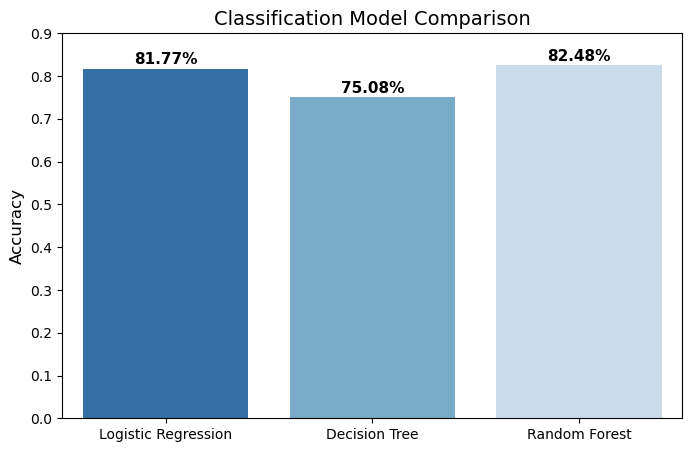

In [71]:
# let's graph them against each other

import matplotlib.pyplot as plt
import seaborn as sns

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy = [accuracy_score(y_test, y_pred_log), 
            accuracy_score(y_test, y_pred_dt), 
            accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8,5))
bars = sns.barplot(x=models, y=accuracy, palette='Blues_r')

for i, acc in enumerate(accuracy):
    plt.text(i, acc + 0.01, f"{acc*100:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Classification Model Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 0.9)
plt.show()

In [72]:
# now for some hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {'C': [0.1,1,10], 'solver': ['liblinear', 'lbfgs']}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_lr.fit(X_train, y_train)
print("Best logistic regression params:", grid_lr.best_params_)
print("Best logistic regression accuracy:", grid_lr.best_score_)

Best logistic regression params: {'C': 0.1, 'solver': 'liblinear'}
Best logistic regression accuracy: 0.8143046458354674


In [74]:
# so hyperparameter tuning didn't make the logistic regression accuracy any better...
# now for decision tree
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {'max_depth': [5,10,None], 'min_samples_split': [2,5]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_dt.fit(X_train, y_train)
print("Best decision tree params:", grid_dt.best_params_)
print("Best decision tree accuracy:", grid_dt.best_score_)

Best decision tree params: {'max_depth': 5, 'min_samples_split': 2}
Best decision tree accuracy: 0.8141258429177644


In [75]:
# hyperparameter tuning made accuracy jump from 75.08% to 81.41% for decision tree!!
# finally, trying on random forest
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {'n_estimators': [50,100], 'max_depth': [5,10]}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

grid_rf.fit(X_train, y_train)
print("Best random forest params:", grid_rf.best_params_)
print("Best random forest accuracy:", grid_rf.best_score_)

Best random forest params: {'max_depth': 10, 'n_estimators': 50}
Best random forest accuracy: 0.7663818192560264


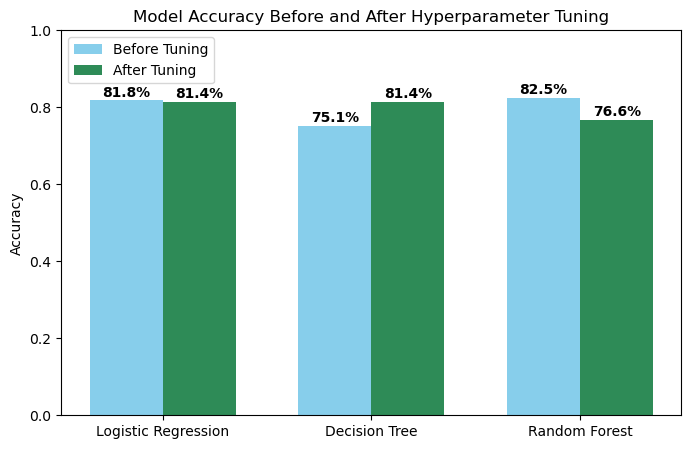

In [76]:
# much worse with the hyperparameter tuning... let's compare all of them pre and post tuning
acc_before = {
    'Logistic Regression': accuracy_score(y_test, y_pred_log),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf)
}

acc_after = {
    'Logistic Regression': grid_lr.best_score_,
    'Decision Tree': grid_dt.best_score_,
    'Random Forest': grid_rf.best_score_
}

import matplotlib.pyplot as plt
import numpy as np

models = list(acc_before.keys())

before_vals = list(acc_before.values())
after_vals = list(acc_after.values())

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, before_vals, width, label='Before Tuning', color='skyblue')
plt.bar(x + width/2, after_vals, width, label='After Tuning', color='seagreen')

for i, v in enumerate(before_vals):
    plt.text(i - width/2, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=10, fontweight='bold')
for i, v in enumerate(after_vals):
    plt.text(i + width/2, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.xticks(x, models)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Before and After Hyperparameter Tuning')
plt.ylim(0, 1)
plt.legend()
plt.show()

*REGRESSION FOR OVERALL COLUMN*

In [77]:
df2 = pd.read_csv("cleaned_fifa_final.csv")

X2 = df2.drop(['Overall'], axis=1)
y2 = df2['Overall']

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [79]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 11185
Testing samples: 2797


In [85]:
# 1. Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X2_train, y2_train)
y2_pred_lin = lin_model.predict(X2_test)

print("R²:", r2_score(y2_test, y2_pred_lin))

R²: 0.8897142583095535


In [86]:
# 2. Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X2_train, y2_train)
y2_pred_dt = dt_reg.predict(X2_test)

print("R²:", r2_score(y2_test, y2_pred_dt))

R²: 0.9917094086335501


In [87]:
# 3. Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X2_train, y2_train)
y2_pred_rf = rf_reg.predict(X2_test)

print("R²:", r2_score(y2_test, y2_pred_rf))

R²: 0.9951347632237536


C:\Users\muham\AppData\Local\Temp\ipykernel_36672\1719861133.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=r2_scores, palette='Greens_r')


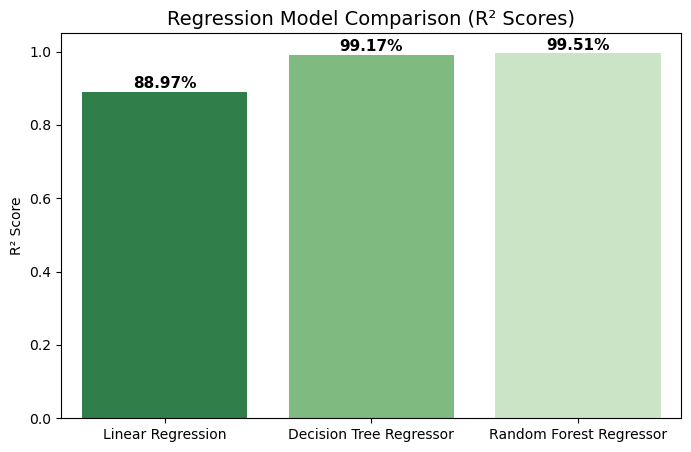

In [89]:
models = ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor']

r2_scores = [
    r2_score(y2_test, y2_pred_lin),
    r2_score(y2_test, y2_pred_dt),
    r2_score(y2_test, y2_pred_rf)
]

plt.figure(figsize=(8,5))
bars = sns.barplot(x=models, y=r2_scores, palette='Greens_r')

for i, score in enumerate(r2_scores):
    plt.text(i, score + 0.01, f"{score*100:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Regression Model Comparison (R² Scores)', fontsize=14)
plt.ylabel('R² Score')
plt.ylim(0, 1.05)
plt.show()

In [90]:
# hyperparameter tuning for the regression algorithms!
# linear regression...

param_grid_lin = {'fit_intercept': [True, False], 'positive': [True, False]}

grid_lin = GridSearchCV(
    LinearRegression(), 
    param_grid_lin, 
    cv=3, 
    scoring='r2', 
    n_jobs=-1)

grid_lin.fit(X2_train, y2_train)
print("Best Linear Regression Params:", grid_lin.best_params_)
print("Best Linear Regression R²:", grid_lin.best_score_)

Best Linear Regression Params: {'fit_intercept': False, 'positive': False}
Best Linear Regression R²: 0.8803834914876839


In [91]:
# decision tree regressor...

param_grid_dt_r = {'max_depth': [5,10,None], 'min_samples_split': [2,5]}

grid_dt_r = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt_r,
    cv=3, 
    scoring='r2',
    n_jobs=-1)

grid_dt_r.fit(X2_train, y2_train)
print("Best Decision Tree Regressor Params:", grid_dt_r.best_params_)
print("Best Decision Tree Regressor R²:", grid_dt_r.best_score_)

Best Decision Tree Regressor Params: {'max_depth': 10, 'min_samples_split': 2}
Best Decision Tree Regressor R²: 0.9905825697460128


In [92]:
# random forest regressor...

param_grid_rf_r = {'n_estimators': [50,100], 'max_depth': [5,10]}

grid_rf_r = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_r,
    cv=3,
    scoring='r2',
    n_jobs=-1)

grid_rf_r.fit(X2_train, y2_train)
print("Best Random Forest Regression Params:", grid_rf_r.best_params_)
print("Best Random Forest Regression R²:", grid_rf_r.best_score_)

Best Random Forest Regression Params: {'max_depth': 10, 'n_estimators': 100}
Best Random Forest Regression R²: 0.9934521192632763


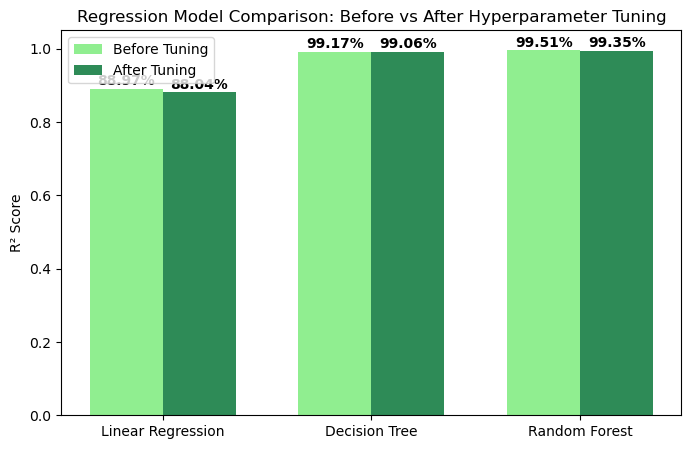

,Model,Before Tuning (R²),After Tuning (R²)
0,Linear Regression,0.889714,0.880383
1,Decision Tree,0.991709,0.990583
2,Random Forest,0.995135,0.993452


In [93]:
r2_before = {
    'Linear Regression': r2_score(y2_test, y2_pred_lin),
    'Decision Tree': r2_score(y2_test, y2_pred_dt),
    'Random Forest': r2_score(y2_test, y2_pred_rf)
}

r2_after = {
    'Linear Regression': grid_lin.best_score_,
    'Decision Tree': grid_dt_r.best_score_,
    'Random Forest': grid_rf_r.best_score_
}

models = list(r2_before.keys())
before_vals = list(r2_before.values())
after_vals = list(r2_after.values())

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, before_vals, width, label='Before Tuning', color='lightgreen')
plt.bar(x + width/2, after_vals, width, label='After Tuning', color='seagreen')

for i, v in enumerate(before_vals):
    plt.text(i - width/2, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=10, fontweight='bold')
for i, v in enumerate(after_vals):
    plt.text(i + width/2, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Regression Model Comparison: Before vs After Hyperparameter Tuning')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

r2_summary = pd.DataFrame({
    'Model': models,
    'Before Tuning (R²)': before_vals,
    'After Tuning (R²)': after_vals
})
r2_summary

In [94]:
# hyperparameter tuning didn't improve any of the regression models surprisingly!
# maybe because my parameter range was very small